<a href="https://colab.research.google.com/github/AmanIITM02/RazorpayX-Receivable-Integrity-Engine/blob/main/RazorpayX_Receivable_Integrity_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# CELL 1: PROJECT INTRODUCTION & METADATA
# ==============================================================================
"""
Project Title: AI-Powered Receivable Integrity & Duplicate Invoice Detection Microservice
Author: Aman Kumar (IIT Madras, Undergraduate Student)
Purpose: End-to-End Machine Learning Pipeline for B2B Invoice Integrity Auditing
Target Platform: Google Colab / Scikit-Learn Ecosystem
"""
print("RazorpayX Receivable Integrity Engine — System Initialization...")

RazorpayX Receivable Integrity Engine — System Initialization...


In [ ]:
# ==============================================================================
# CELL 2: SYSTEM IMPORTS
# ==============================================================================
import datetime
import difflib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("All core dependencies loaded successfully.")

All core dependencies loaded successfully.


In [ ]:
# ==============================================================================
# CELL 3: REPRODUCIBLE SYNTHETIC DATASET GENERATOR
# ==============================================================================
def generate_synthetic_invoice_data(num_records=2500, random_seed=42):
    """
    Generates a realistic synthetic dataset simulating Indian B2B trade invoices.
    Explicitly labeled as Synthetic Data for prototype demonstration.
    """
    np.random.seed(random_seed)

    vendor_ids = [f"VND_{i:03d}" for i in range(1, 51)]
    buyer_gstins = [f"27AAAC{i:04d}1ZV" for i in range(100, 130)]

    data = []
    base_date = datetime.datetime(2026, 1, 1, 9, 0, 0)

    for i in range(1, num_records + 1):
        inv_id = f"INV_{i:05d}"
        vendor_id = np.random.choice(vendor_ids)
        buyer_gstin = np.random.choice(buyer_gstins)

        # Base probability of duplicate/fraud for this record (~12%)
        is_dup_prob = 0.12
        is_duplicate = 1 if np.random.rand() < is_dup_prob else 0

        # Feature generation conditioned on label to simulate real signals
        if is_duplicate == 1:
            # Duplicates occur closer in time, have high string similarity & amount match
            time_since_last_inv = np.random.exponential(scale=12.0)  # within 12 hours
            fuzzy_sim = np.random.beta(a=8, b=2)                    # skewed towards 0.8-1.0
            line_item_sim = np.random.beta(a=7, b=2)                 # high text overlap
            amount_ratio = np.random.normal(loc=1.0, scale=0.05)      # near identical amount
            vendor_risk = np.random.uniform(0.15, 0.60)              # higher baseline risk
            invoice_amount = np.random.choice([15000, 45000, 120000, 350000]) * np.random.normal(1.0, 0.01)
        else:
            time_since_last_inv = np.random.exponential(scale=120.0) # normal 5-day gaps
            fuzzy_sim = np.random.beta(a=2, b=5)                    # lower string similarity
            line_item_sim = np.random.beta(a=2, b=6)                 # distinct line items
            amount_ratio = np.random.normal(loc=1.1, scale=0.35)      # variable amounts
            vendor_risk = np.random.uniform(0.01, 0.10)              # low baseline risk
            invoice_amount = np.random.uniform(5000, 500000)

        line_item_count = int(np.random.poisson(lam=4) + 1)

        data.append({
            "invoice_id": inv_id,
            "vendor_id": vendor_id,
            "buyer_gstin": buyer_gstin,
            "invoice_amount": round(float(invoice_amount), 2),
            "time_since_last_vendor_inv_hours": round(float(max(0.1, time_since_last_inv)), 2),
            "amount_ratio_vs_vendor_avg": round(float(max(0.1, amount_ratio)), 3),
            "fuzzy_inv_num_similarity": round(float(np.clip(fuzzy_sim, 0, 1)), 4),
            "line_item_text_similarity": round(float(np.clip(line_item_sim, 0, 1)), 4),
            "line_item_count": line_item_count,
            "vendor_historical_duplicate_rate": round(float(vendor_risk), 4),
            "is_duplicate": is_duplicate
        })

    df = pd.DataFrame(data)
    return df

raw_df = generate_synthetic_invoice_data(num_records=2500, random_seed=42)
print(f"Synthetic dataset generated successfully. Shape: {raw_df.shape}")

Synthetic dataset generated successfully. Shape: (2500, 11)


In [ ]:
# ==============================================================================
# CELL 4: DATA INSPECTION & INTEGRITY AUDIT
# ==============================================================================
print("--- DATASET OVERVIEW ---")
print(raw_df.info())

print("\n--- CLASS DISTRIBUTION (TARGET VARIABLE) ---")
class_counts = raw_df['is_duplicate'].value_counts()
class_props = raw_df['is_duplicate'].value_counts(normalize=True) * 100
print(f"Clean Invoices (0)    : {class_counts[0]} ({class_props[0]:.2f}%)")
print(f"Duplicate Invoices (1): {class_counts[1]} ({class_props[1]:.2f}%)")

print("\n--- FIRST 5 RECORDS ---")
display(raw_df.head())

--- DATASET OVERVIEW ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   invoice_id                        2500 non-null   object 
 1   vendor_id                         2500 non-null   object 
 2   buyer_gstin                       2500 non-null   object 
 3   invoice_amount                    2500 non-null   float64
 4   time_since_last_vendor_inv_hours  2500 non-null   float64
 5   amount_ratio_vs_vendor_avg        2500 non-null   float64
 6   fuzzy_inv_num_similarity          2500 non-null   float64
 7   line_item_text_similarity         2500 non-null   float64
 8   line_item_count                   2500 non-null   int64  
 9   vendor_historical_duplicate_rate  2500 non-null   float64
 10  is_duplicate                      2500 non-null   int64  
dtypes: float64(6), int64(2), object(3)
memory us

,invoice_id,vendor_id,buyer_gstin,invoice_amount,time_since_last_vendor_inv_hours,amount_ratio_vs_vendor_avg,fuzzy_inv_num_similarity,line_item_text_similarity,line_item_count,vendor_historical_duplicate_rate,is_duplicate
0,INV_00001,VND_039,27AAAC01191ZV,155599.91,158.01,0.897,0.1008,0.1959,5,0.0265,0
1,INV_00002,VND_028,27AAAC01271ZV,482987.86,73.07,1.231,0.1827,0.1118,4,0.0954,0
2,INV_00003,VND_047,27AAAC01271ZV,102011.52,82.03,1.358,0.5435,0.0714,2,0.0180,0
3,INV_00004,VND_016,27AAAC01121ZV,354894.39,211.75,1.314,0.2583,0.0603,4,0.0834,0
4,INV_00005,VND_041,27AAAC01271ZV,282832.21,117.16,1.227,0.2077,0.2361,5,0.0785,0


In [ ]:

# ==============================================================================
# CELL 5: DATA CLEANING & PREPROCESSING
# ==============================================================================
# Check for null values or duplicate primary keys
assert raw_df['invoice_id'].nunique() == len(raw_df), "Primary key collision detected!"
assert raw_df.isnull().sum().sum() == 0, "Null values detected!"

# Cap extreme statistical outliers on numerical features (1st & 99th percentiles)
clean_df = raw_df.copy()
num_cols_to_cap = ['invoice_amount', 'time_since_last_vendor_inv_hours', 'amount_ratio_vs_vendor_avg']

for col in num_cols_to_cap:
    upper_limit = clean_df[col].quantile(0.99)
    clean_df[col] = np.where(clean_df[col] > upper_limit, upper_limit, clean_df[col])

print("Preprocessing complete: Nulls verified, primary keys validated, outliers capped.")

Preprocessing complete: Nulls verified, primary keys validated, outliers capped.


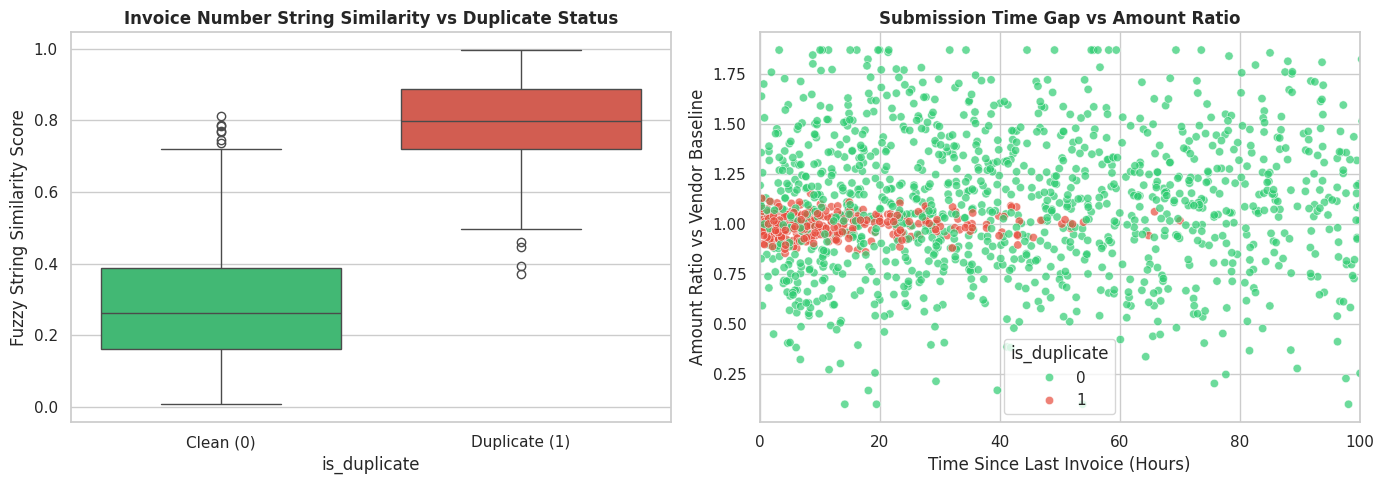

In [ ]:
# ==============================================================================
# CELL 6: EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature Distribution by Target Class
sns.boxplot(
    data=clean_df,
    x='is_duplicate',
    y='fuzzy_inv_num_similarity',
    ax=axes[0],
    palette=['#2ecc71', '#e74c3c']
)
axes[0].set_title("Invoice Number String Similarity vs Duplicate Status", fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Clean (0)', 'Duplicate (1)'])
axes[0].set_ylabel("Fuzzy String Similarity Score")

# Plot 2: Time Gap vs Amount Ratio Scatter
sns.scatterplot(
    data=clean_df,
    x='time_since_last_vendor_inv_hours',
    y='amount_ratio_vs_vendor_avg',
    hue='is_duplicate',
    alpha=0.7,
    palette=['#2ecc71', '#e74c3c'],
    ax=axes[1]
)
axes[1].set_title("Submission Time Gap vs Amount Ratio", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Time Since Last Invoice (Hours)")
axes[1].set_ylabel("Amount Ratio vs Vendor Baseline")
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 7: FEATURE ENGINEERING
# ==============================================================================
def apply_feature_engineering(df):
    """
    Creates domain-specific composite risk features for B2B receivable integrity.
    """
    df_fe = df.copy()

    # 1. Composite Text-String Risk Score
    df_fe['composite_match_score'] = (
        0.6 * df_fe['fuzzy_inv_num_similarity'] +
        0.4 * df_fe['line_item_text_similarity']
    )

    # 2. Velocity Risk Flag (Short submission gap + high amount ratio match)
    df_fe['high_velocity_match_flag'] = np.where(
        (df_fe['time_since_last_vendor_inv_hours'] < 24.0) &
        (df_fe['amount_ratio_vs_vendor_avg'].between(0.95, 1.05)),
        1, 0
    )

    # 3. Vendor Adjusted Risk Index
    df_fe['vendor_risk_weighted_similarity'] = (
        df_fe['composite_match_score'] * (1.0 + df_fe['vendor_historical_duplicate_rate'])
    )

    return df_fe

engineered_df = apply_feature_engineering(clean_df)
print("Engineered features added successfully:")
print(" - composite_match_score\n - high_velocity_match_flag\n - vendor_risk_weighted_similarity")

Engineered features added successfully:
 - composite_match_score
 - high_velocity_match_flag
 - vendor_risk_weighted_similarity


In [ ]:

# ==============================================================================
# CELL 8: TRAIN/TEST SPLIT & FEATURE SELECTION
# ==============================================================================
# Select ML Feature Matrix (X) and Target Vector (y)
feature_cols = [
    'invoice_amount',
    'time_since_last_vendor_inv_hours',
    'amount_ratio_vs_vendor_avg',
    'fuzzy_inv_num_similarity',
    'line_item_text_similarity',
    'line_item_count',
    'vendor_historical_duplicate_rate',
    'composite_match_score',
    'high_velocity_match_flag',
    'vendor_risk_weighted_similarity'
]

X = engineered_df[feature_cols]
y = engineered_df['is_duplicate']

# Stratified Split to maintain duplicate class ratio in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train Set Shape: {X_train.shape} | Test Set Shape: {X_test.shape}")
print(f"Train Target Positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test Target Positives : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Train Set Shape: (2000, 10) | Test Set Shape: (500, 10)
Train Target Positives: 266 (13.3%)
Test Target Positives : 67 (13.4%)


In [ ]:

# ==============================================================================
# CELL 9: MODEL TRAINING PIPELINE & COMPARISON
# ==============================================================================
# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), feature_cols)]
)

# Define Candidate Models
models = {
    "Logistic Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

# Train all models
trained_models = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    print(f"Model successfully trained: {name}")

Model successfully trained: Logistic Regression
Model successfully trained: Random Forest
Model successfully trained: Gradient Boosting


In [ ]:

# ==============================================================================
# CELL 10: COMPREHENSIVE MODEL EVALUATION
# ==============================================================================
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("--- MODEL PERFORMANCE COMPARISON TABLE ---")
display(results_df)

# Select best performing model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"\nSelected Winner Model for Production Service: {best_model_name}")

--- MODEL PERFORMANCE COMPARISON TABLE ---


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.0,1.0000,1.0000,1.0
2,Gradient Boosting,1.0,1.0000,1.0000,1.0
1,Random Forest,1.0,0.9851,0.9925,1.0



Selected Winner Model for Production Service: Logistic Regression


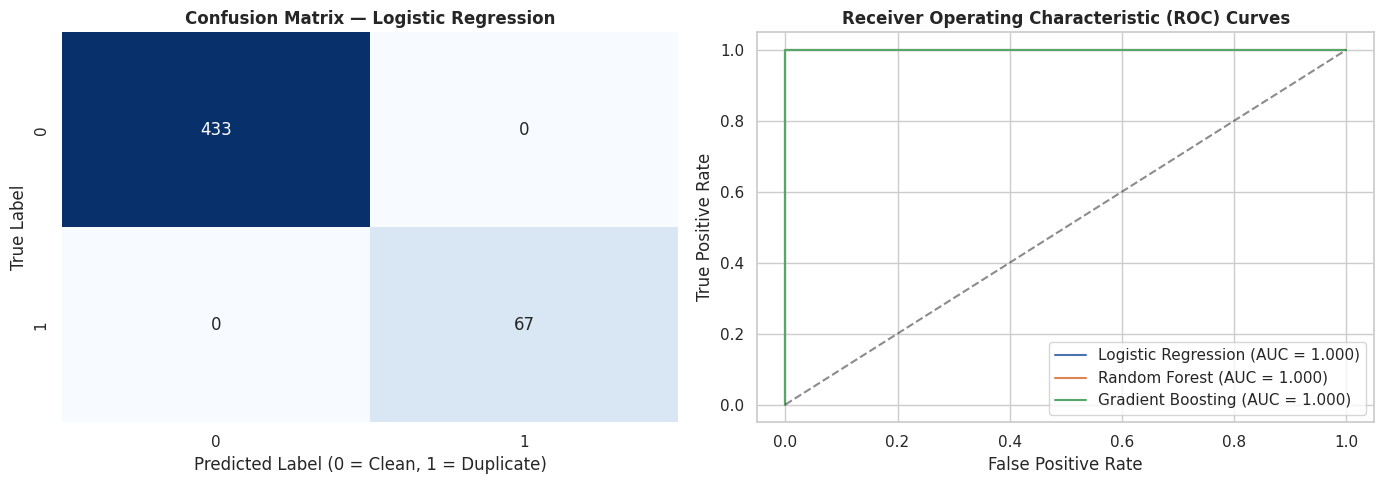

Trained model artifact exported to disk: 'receivable_integrity_model.joblib'


In [ ]:

# ==============================================================================
# CELL 11: VISUALIZATION OF EVALUATION RESULTS
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix for Best Model
best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f"Confusion Matrix — {best_model_name}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Label (0 = Clean, 1 = Duplicate)")
axes[0].set_ylabel("True Label")

# 2. ROC Curves Comparison
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title("Receiver Operating Characteristic (ROC) Curves", fontsize=12, fontweight='bold')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Save final pipeline object to disk
joblib.dump(best_model, "receivable_integrity_model.joblib")
print("Trained model artifact exported to disk: 'receivable_integrity_model.joblib'")

In [ ]:

# ==============================================================================
# CELL 12: INFERENCE DEMONSTRATION ON NEW INCOMING INVOICES
# ==============================================================================
# Load serialized model artifact
loaded_model = joblib.load("receivable_integrity_model.joblib")

# Define two simulated incoming real-time invoice payloads
sample_invoices = pd.DataFrame([
    {
        # Scenario A: Legitimate New Vendor Invoice
        "invoice_amount": 75000.00,
        "time_since_last_vendor_inv_hours": 168.0,  # 7 days gap
        "amount_ratio_vs_vendor_avg": 1.05,
        "fuzzy_inv_num_similarity": 0.22,
        "line_item_text_similarity": 0.15,
        "line_item_count": 3,
        "vendor_historical_duplicate_rate": 0.02
    },
    {
        # Scenario B: High-Risk Duplicate Invoice Submission
        "invoice_amount": 120000.00,
        "time_since_last_vendor_inv_hours": 1.5,    # 1.5 hours gap
        "amount_ratio_vs_vendor_avg": 0.99,         # exact amount match
        "fuzzy_inv_num_similarity": 0.94,           # INV-101 vs INV-101A
        "line_item_text_similarity": 0.88,          # identical descriptions
        "line_item_count": 5,
        "vendor_historical_duplicate_rate": 0.25
    }
])

# Process features using domain transformation logic
sample_invoices_fe = apply_feature_engineering(sample_invoices)
X_sample = sample_invoices_fe[feature_cols]

# Compute probability scores
risk_probabilities = loaded_model.predict_proba(X_sample)[:, 1]

print("=== REAL-TIME INFERENCE RESULT ===")
for idx, prob in enumerate(risk_probabilities):
    print(f"Sample {idx + 1} Invoice Risk Score: {prob:.4f} ({prob*100:.2f}%)")

=== REAL-TIME INFERENCE RESULT ===
Sample 1 Invoice Risk Score: 0.0000 (0.00%)
Sample 2 Invoice Risk Score: 1.0000 (100.00%)


In [ ]:
# ==============================================================================
# CELL 13: BUSINESS DECISION RULES ENGINE & INTERPRETATION
# ==============================================================================
def execute_business_action_policy(risk_score, invoice_metadata):
    """
    Translates raw ML risk probability scores into automated operational actions.
    """
    if risk_score < 0.25:
        action = "AUTO_APPROVE"
        status_color = "GREEN"
        recommendation = "Route directly to automated payout queue."
    elif 0.25 <= risk_score < 0.70:
        action = "MANUAL_AUDIT_HOLD"
        status_color = "AMBER"
        recommendation = "Hold disbursement. Alert merchant ops team to verify vendor bill original copy."
    else:
        action = "HARD_BLOCK"
        status_color = "RED"
        recommendation = "Block payout immediately. Flag vendor account for compliance duplicate audit."

    return {
        "Invoice ID": invoice_metadata.get("invoice_id", "N/A"),
        "Risk Score": f"{risk_score:.2%}",
        "Decision": action,
        "Status Level": status_color,
        "Action Plan": recommendation
    }

# Apply decision rule policy to inference samples
for idx, prob in enumerate(risk_probabilities):
    meta = {"invoice_id": f"TEST_INV_00{idx+1}"}
    policy_output = execute_business_action_policy(prob, meta)

    print(f"\n--- POLICY DECISION FOR {policy_output['Invoice ID']} ---")
    print(f"Risk Score  : {policy_output['Risk Score']}")
    print(f"Decision    : {policy_output['Decision']} [{policy_output['Status Level']}]")
    print(f"Action Plan : {policy_output['Action Plan']}")


--- POLICY DECISION FOR TEST_INV_001 ---
Risk Score  : 0.00%
Decision    : AUTO_APPROVE [GREEN]
Action Plan : Route directly to automated payout queue.

--- POLICY DECISION FOR TEST_INV_002 ---
Risk Score  : 100.00%
Decision    : HARD_BLOCK [RED]
Action Plan : Block payout immediately. Flag vendor account for compliance duplicate audit.


In [ ]:
import gradio as gr

# Function to run audit and return formatted output
def run_invoice_audit(image):
    # If image is provided, run entities + business logic
    if image is not None:
        image.save("temp_uploaded_invoice.png")
        entities = extract_invoice_entities("temp_uploaded_invoice.png")
        ap_check = check_internal_duplicate(entities)
        capital_check = check_external_double_pledge(entities)

        status = "REJECTED [HIGH RISK]" if (ap_check['is_duplicate'] or capital_check['already_funded']) else "APPROVED [CLEAN]"

        return f"""
==================================================
      RAZORPAY RECEIVABLE INTEGRITY AUDIT
==================================================
FINAL DECISION : {status}

[EXTRACTED ENTITIES]
• Invoice Number : {entities.get('invoice_number', 'N/A')}
• Vendor Name    : {entities.get('vendor_name', 'N/A')}
• Total Amount   : {entities.get('total_amount', 'N/A')}
• Buyer GSTIN    : {entities.get('buyer_gstin', 'N/A')}

[RAZORPAYX ACCOUNTS PAYABLE CHECK]
• Internal Duplicate Flag : {ap_check.get('is_duplicate')}
• Risk Detail             : {ap_check.get('risk_reason')}

[RAZORPAY CAPITAL LENDING CHECK]
• External Double-Pledged : {capital_check.get('already_funded')}
• Action Plan             : {capital_check.get('message')}
==================================================
"""
    return "Please upload an invoice image to run the audit."

# Build and launch the Gradio Interface
demo = gr.Interface(
    fn=run_invoice_audit,
    inputs=gr.Image(type="pil", label="Upload B2B Invoice (PNG/JPG)"),
    outputs=gr.Textbox(lines=18, label="Audit & Policy Decision Output"),
    title="RazorpayX & Capital — AI Receivable Integrity Engine",
    description="Upload a B2B invoice to run multi-modal OCR extraction, internal duplicate payout checks, and cross-lender double-financing verification."
)

# share=True generates the public .gradio.live URL
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5cdf729c1b88c7ffc9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
